# First-Visit Monte Carlo Control for Blackjack-v1

In [1]:
# DONE: Imports and setup
import sys
sys.path.insert(0, "../src")

import gymnasium as gym
import numpy as np

import warnings
warnings.filterwarnings("ignore")

NUM_EPISODES = 1_000_000
WINDOW_SIZE = NUM_EPISODES // 20  # 5% of episodes

def summarize_rewards(rewards, tail=None):
    """Return (mean, ci_lower, ci_upper) for a reward series."""
    arr = np.array(rewards[-tail:] if tail else rewards)
    mean = arr.mean()
    ci = 1.96 * arr.std() / np.sqrt(len(arr))
    return mean, mean - ci, mean + ci

def print_results(results, tail=None, agents=None):
    """Display avg return and 95% CI for each agent as a DataFrame."""
    import pandas as pd
    rows = []
    for name, rewards in results.items():
        mean, ci_lo, ci_hi = summarize_rewards(rewards, tail=tail)
        row = {"Agent": name, "Avg Return": f"{mean:.3f}",
               "95% CI": f"[{ci_lo:.3f}, {ci_hi:.3f}]"}
        if agents and name in agents:
            agent = agents[name]
            if hasattr(agent, 'returns_count') and agent.returns_count:
                states_visited = len(set(s for (s, a) in agent.returns_count))
                avg_visits = np.mean(list(agent.returns_count.values()))
                row["States"] = states_visited
                row["Avg Visits/State"] = f"{avg_visits:.1f}"
        rows.append(row)
    df = pd.DataFrame(rows)
    df["_sort"] = df["Avg Return"].astype(float)
    return df.sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)


## BlackjackAgent

In [2]:
# DONE: BlackjackAgent - stub
# - __init__(epsilon, discount_factor): initialize Q-values, returns_sum,
#   returns_count, and epsilon-soft policy
# - select_action(state): return action using epsilon-soft policy
# - update(episode): first-visit MC update from a complete episode trajectory
#   - Work backward through episode to compute returns
#   - Update Q-values only for first visits to each (state, action) pair
# - get_policy(): return greedy policy derived from Q-values
# - get_value_function(): return state-value function (max Q over actions)

In [3]:
# DONE: BlackjackAgent - unit tests
# See src/test_blackjack_agent.py for full test suite
!cd ../src && python -m pytest test_blackjack_agent.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 20 items                                                             

test_blackjack_agent.py::TestBlackjackAgentStub::test_constructor_sets_epsilon PASSED [  5%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_constructor_sets_discount_factor PASSED [ 10%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_select_action_returns_valid_action PASSED [ 15%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_select_action_returns_int PASSED [ 20%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_update_accepts_episode PASSED [ 25%]
test_blackjack_agent.py::TestBlackjackAgentStub::test_get_policy_returns_dict PASSED [ 30%]
test_blackjack_agent.py::TestBlackjackAgentStub:

In [4]:
# DONE: BlackjackAgent - demo
from blackjack_agent import BlackjackAgent

agent = BlackjackAgent(epsilon=0.1, discount_factor=1.0)
state = (18, 6, False)
action = agent.select_action(state)
print(f"State: {state} -> Action: {'Hit' if action == 1 else 'Stick'}")
print(f"Policy: {agent.get_policy()}")
print(f"Value function: {agent.get_value_function()}")

State: (18, 6, False) -> Action: Stick
Policy: {(18, 6, False): 0}
Value function: {(18, 6, False): 0.0}


In [5]:
# DONE: BlackjackAgent - epsilon decay
# - decay_epsilon() calls injected decay_schedule callable
# - Supports any callable: lambdas for linear/exponential,
#   callable objects with internal state for cosine
# - Default is no decay (backward compatible)

## EpisodeRunner

In [6]:
# DONE: EpisodeRunner - stub
# - __init__(env): wrap a Gymnasium Blackjack-v1 environment
# - run_episode(agent): generate one complete episode trajectory
#   - env.reset() to start, collect (state, action, reward) tuples via env.step()
#   - Continue until terminated flag is True
#   - Return trajectory as a list of (state, action, reward)
# - run_training(agent, NUM_EPISODES): run multiple episodes, update agent after each
#   - Track per-episode rewards for learning curves
#   - Return list of episode rewards

In [7]:
# DONE: EpisodeRunner - demo (verbose)
from episode_runner import EpisodeRunner

env = gym.make("Blackjack-v1", sab=True)
runner = EpisodeRunner(env)
episode = runner.run_episode(agent, verbose=True)

Step 1: State=(sum=17, dealer=5, ace=False) Action=Stick Reward=1.0
Episode finished: 1 steps, Result=Win


In [8]:
# DONE: EpisodeRunner - unit tests
# See src/test_episode_runner.py for full test suite
!cd ../src && python -m pytest test_episode_runner.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 15 items                                                             

test_episode_runner.py::TestEpisodeRunnerStub::test_run_episode_returns_list PASSED [  6%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_episode_returns_nonempty PASSED [ 13%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_episode_tuple_structure PASSED [ 20%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_training_returns_rewards_list PASSED [ 26%]
test_episode_runner.py::TestEpisodeRunnerStub::test_run_training_rewards_are_numeric PASSED [ 33%]
test_episode_runner.py::TestEpisodeRunnerVerbose::test_verbose_false_produces_no_output PASSED [ 40%]
test_episode_runner.py::TestEpisodeRunner

In [9]:
# DONE: Integration - Agent + Runner
# See src/test_integration_cycle1.py for full test suite
!cd ../src && python -m pytest test_integration_cycle1.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 4 items                                                              

test_integration_cycle1.py::TestAgentRunnerIntegration::test_episode_feeds_into_agent_update PASSED [ 25%]
test_integration_cycle1.py::TestAgentRunnerIntegration::test_training_loop_updates_agent PASSED [ 50%]
test_integration_cycle1.py::TestAgentRunnerIntegration::test_training_loop_collects_rewards PASSED [ 75%]
test_integration_cycle1.py::TestAgentRunnerIntegration::test_agent_actions_are_valid_throughout_episode PASSED [100%]

============================== 4 passed in 0.13s ===============================


## BasicStrategy

In [10]:
# DONE: BasicStrategy - stub
# - __init__(): encode standard Blackjack basic strategy lookup tables
#   - Separate tables for hard totals and soft totals (usable ace)
# - get_action(state): return the basic strategy action for a given state
# - select_action(state): EpisodeRunner-compatible alias for get_action
# - update(episode): no-op for EpisodeRunner compatibility

In [11]:
# DONE: BasicStrategy - demo
from basic_strategy import BasicStrategy

strategy = BasicStrategy()
test_states = [(20, 6, False), (12, 2, False), (18, 9, True), (16, 10, False)]
for s in test_states:
    action = strategy.get_action(s)
    print(f"State={s} -> {'Hit' if action == 1 else 'Stick'}")

State=(20, 6, False) -> Stick
State=(12, 2, False) -> Hit
State=(18, 9, True) -> Hit
State=(16, 10, False) -> Hit


In [12]:
# DONE: BasicStrategy - unit tests + integration
# See src/test_basic_strategy.py for full test suite
!cd ../src && python -m pytest test_basic_strategy.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 16 items                                                             

test_basic_strategy.py::TestBasicStrategyActions::test_stand_on_20 PASSED [  6%]
test_basic_strategy.py::TestBasicStrategyActions::test_stand_on_19 PASSED [ 12%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_8 PASSED   [ 18%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_5 PASSED   [ 25%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_12_vs_dealer_2 PASSED [ 31%]
test_basic_strategy.py::TestBasicStrategyActions::test_stand_on_12_vs_dealer_4 PASSED [ 37%]
test_basic_strategy.py::TestBasicStrategyActions::test_hit_on_16_vs_dealer_10 PASSED [ 43%]
test_basic_strategy.py::

## NaiveAgent

In [13]:
# DONE: NaiveAgent - stub
# - Implements select_action(state) and no-op update(episode)
#   to be compatible with EpisodeRunner
# - Three strategies: random, always_hit, always_stick
# - Serves as the performance floor in the bake-off

In [14]:
# DONE: NaiveAgent - demo
from naive_agent import NaiveAgent

for strat in ("random", "always_hit", "always_stick"):
    naive = NaiveAgent(strategy=strat)
    state = (16, 10, False)
    action = naive.select_action(state)
    print(f"Strategy={strat}: State={state} -> {'Hit' if action == 1 else 'Stick'}")

Strategy=random: State=(16, 10, False) -> Hit
Strategy=always_hit: State=(16, 10, False) -> Hit
Strategy=always_stick: State=(16, 10, False) -> Stick


In [15]:
# DONE: NaiveAgent - unit tests + integration
# See src/test_naive_agent.py for full test suite
!cd ../src && python -m pytest test_naive_agent.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 7 items                                                              

test_naive_agent.py::TestNaiveAgentActions::test_random_returns_valid_action PASSED [ 14%]
test_naive_agent.py::TestNaiveAgentActions::test_always_hit_returns_hit PASSED [ 28%]
test_naive_agent.py::TestNaiveAgentActions::test_always_stick_returns_stick PASSED [ 42%]
test_naive_agent.py::TestNaiveAgentActions::test_select_action_returns_int PASSED [ 57%]
test_naive_agent.py::TestNaiveAgentActions::test_invalid_strategy_raises PASSED [ 71%]
test_naive_agent.py::TestNaiveAgentIntegration::test_runs_episodes PASSED [ 85%]
test_naive_agent.py::TestNaiveAgentIntegration::test_runs_training_loop PASSED [100%]

===========

## Visualizer

In [16]:
# DONE: Visualizer - stub
# - plot_value_surface(value_function, title, usable_ace): 3D surface plot
#   - X axis: dealer showing (1-10), Y axis: player sum (12-21)
#   - Filtered by usable_ace parameter
# - plot_learning_curve(rewards, window_size): smoothed average returns over episodes
# - plot_bakeoff(results): bar chart comparing average returns across agents
# - save_plot(fig, path): save individual figure to disk, creates directories as needed

In [17]:
# DONE: Visualizer - unit tests
# See src/test_visualizer.py for full test suite
!cd ../src && python -m pytest test_visualizer.py -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 19 items                                                             

test_visualizer.py::TestVisualizerValueSurface::test_returns_figure PASSED [  5%]
test_visualizer.py::TestVisualizerValueSurface::test_usable_ace_plot PASSED [ 10%]
test_visualizer.py::TestVisualizerValueSurface::test_no_usable_ace_plot PASSED [ 15%]
test_visualizer.py::TestVisualizerLearningCurve::test_returns_figure PASSED [ 21%]
test_visualizer.py::TestVisualizerLearningCurve::test_single_episode PASSED [ 26%]
test_visualizer.py::TestVisualizerLearningCurve::test_window_larger_than_data PASSED [ 31%]
test_visualizer.py::TestVisualizerBakeoff::test_returns_figure PASSED    [ 36%]
test_visualizer.py::TestVisualize

## Training

In [18]:
# DONE: Training run infrastructure
# - run_training accepts callback and callback_interval for progress reporting
# - Calls agent.decay_epsilon() after each episode if supported
# - Backward compatible with existing callers

In [19]:
# DONE: Training run - demo (short run to verify)
from blackjack_agent import BlackjackAgent
from episode_runner import EpisodeRunner
from decay_schedules import ExponentialDecay


env = gym.make("Blackjack-v1", sab=True)
agent = BlackjackAgent(epsilon=0.05, decay_schedule=None)

runner = EpisodeRunner(env)

def progress(episode_num, rewards, agent):
    avg = np.mean(rewards[-1000:])
    print(f"Episode {episode_num:>7}: avg return={avg:.3f}, epsilon={agent.epsilon:.4f}, "
          f"states visited={len(agent.get_policy())}")

rewards = runner.run_training(agent, 
                              num_episodes=NUM_EPISODES // 10, 
                              callback=progress, 
                              callback_interval=NUM_EPISODES // 50)

print_results({"Training Run": rewards}, tail=WINDOW_SIZE // 10,
              agents={"Training Run": agent})


Episode   20000: avg return=-0.074, epsilon=0.0500, states visited=280
Episode   40000: avg return=-0.121, epsilon=0.0500, states visited=280
Episode   60000: avg return=-0.117, epsilon=0.0500, states visited=280
Episode   80000: avg return=-0.042, epsilon=0.0500, states visited=280
Episode  100000: avg return=-0.061, epsilon=0.0500, states visited=280


,Agent,Avg Return,95% CI,States,Avg Visits/State
0,Training Run,-0.075,"[-0.101, -0.048]",280,244.8


In [20]:
# DONE: Training run - unit tests
!cd ../src && python -m pytest test_episode_runner.py::TestEpisodeRunnerCallback -v

============================= test session starts ==============================
platform darwin -- Python 3.11.11, pytest-9.0.2, pluggy-1.5.0 -- /Users/crudman/anaconda3/envs/gym_env/bin/python
cachedir: .pytest_cache
rootdir: /Users/crudman/Documents/GitHub/MSDS684/W3/src
plugins: anyio-4.12.1
collected 6 items                                                              

test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_is_called PASSED [ 16%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_receives_correct_episode_num PASSED [ 33%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_receives_rewards_list PASSED [ 50%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_receives_agent PASSED [ 66%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_no_callback_by_default PASSED [ 83%]
test_episode_runner.py::TestEpisodeRunnerCallback::test_callback_with_decay PASSED [100%]

============================== 6 passed in 0.1

## Visualizations

In [21]:
# DONE: Generate visualizations
# - 3D value surface: usable ace
# - 3D value surface: no usable ace
# - Learning curve with smoothed average returns
# - Bake-off bar chart: all agents' average returns

In [22]:
# Bake-off: Learning Curve Overlay
import gymnasium as gym
from blackjack_agent import BlackjackAgent
from naive_agent import NaiveAgent
from basic_strategy import BasicStrategy
from episode_runner import EpisodeRunner
from visualizer import Visualizer
import matplotlib.pyplot as plt

env = gym.make("Blackjack-v1", sab=True)
runner = EpisodeRunner(env)
viz = Visualizer()


# Train MC agent
mc_agent = BlackjackAgent(epsilon=0.01, decay_schedule=None)
mc_rewards = runner.run_training(mc_agent, num_episodes=NUM_EPISODES)

# Run baselines
naive_agent = NaiveAgent(strategy="random")
# naive_agent = NaiveAgent(strategy="always_hit")
# naive_agent = NaiveAgent(strategy="always_stick")
naive_rewards = runner.run_training(naive_agent, num_episodes=NUM_EPISODES)

basic_agent = BasicStrategy()
basic_rewards = runner.run_training(basic_agent, num_episodes=NUM_EPISODES)

# Plot overlay
reward_series = {
    "NaiveRandom": naive_rewards,
    "BasicStrategy": basic_rewards,
    "MC Agent": mc_rewards,
}
print_results(reward_series, tail=WINDOW_SIZE,
              agents={"MC Agent": mc_agent})


,Agent,Avg Return,95% CI,States,Avg Visits/State
0,BasicStrategy,-0.042,"[-0.051, -0.034]",NaN,NaN
1,MC Agent,-0.063,"[-0.071, -0.054]",280.0,2480.9
2,NaiveRandom,-0.391,"[-0.399, -0.383]",NaN,NaN


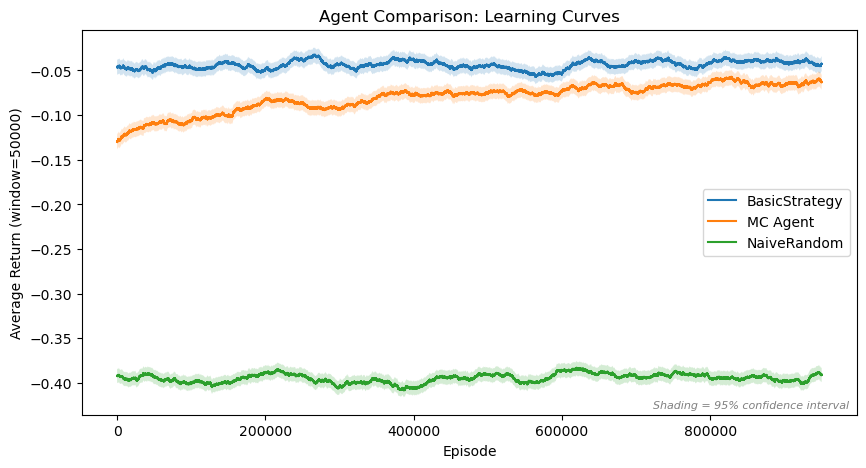

In [23]:
_ = viz.plot_bakeoff_curves(reward_series, 
                            title="Agent Comparison: Learning Curves", 
                            window_size=WINDOW_SIZE, 
                            save_path="../img/bakeoff_learning_curves.png")


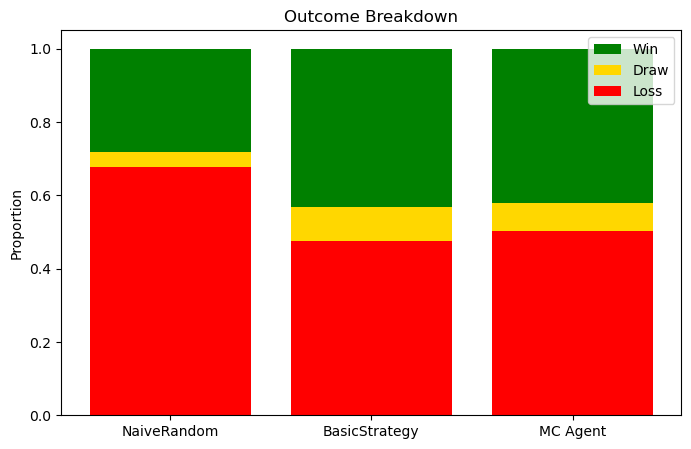

In [24]:
# Bake-off: Outcome Breakdown (stacked bar chart)
fig_outcomes = viz.plot_outcome_breakdown(reward_series, save_path="../img/outcome_breakdown.png")


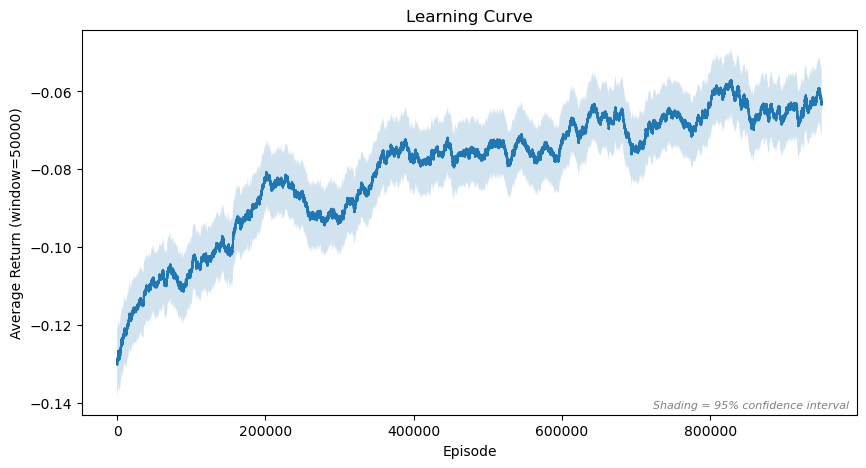

In [25]:
# MC Agent: Learning Curve
fig_lc = viz.plot_learning_curve(mc_rewards, window_size=WINDOW_SIZE, show_ci=True, save_path="../img/mc_learning_curve.png")

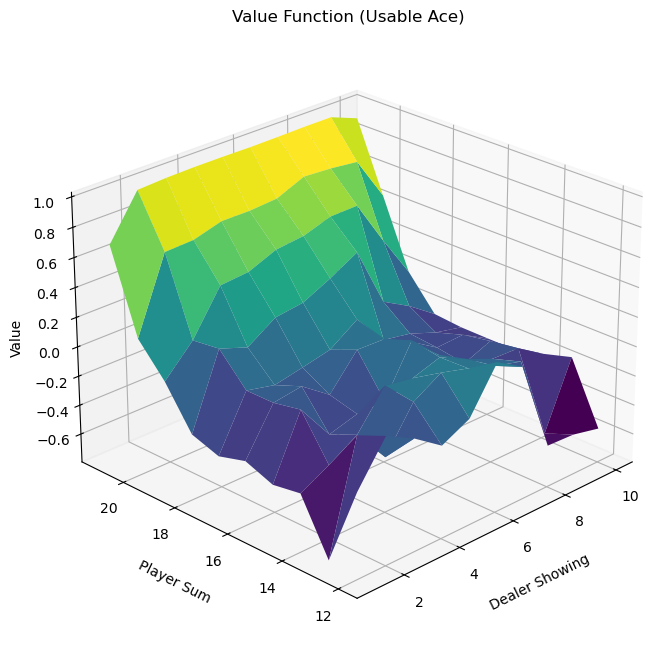

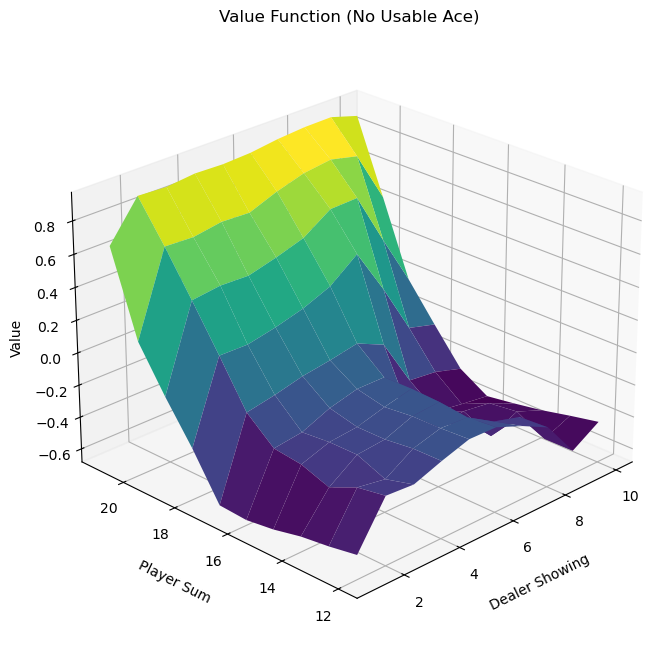

In [26]:
# 3D Value Surface Plots
value_fn = mc_agent.get_value_function()

fig_ace = viz.plot_value_surface(value_fn, "Value Function (Usable Ace)", usable_ace=True,
                                          save_path="../img/value_surface_usable_ace.png")
fig_no_ace = viz.plot_value_surface(value_fn, "Value Function (No Usable Ace)", usable_ace=False,
                                          save_path="../img/value_surface_no_usable_ace.png")



## Epsilon Experimentation

In [27]:
# DONE: Epsilon experimentation
# - Train with different fixed epsilon values (e.g., 0.01, 0.1, 0.3)
# - Train with different decay schedules (e.g., linear, exponential)
# - Compare learning curves across configurations
# - Compare final average returns across configurations

In [28]:
# Experiment 1: Fixed Epsilon (no decay)
# H1: There exists an optimal fixed epsilon that balances exploration
#     and exploitation. Too low = incomplete coverage, too high = no convergence.
from blackjack_agent import BlackjackAgent


fixed_epsilons = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.9]
fixed_results = {}
fixed_agents = {}
for eps in fixed_epsilons:
    agent = BlackjackAgent(epsilon=eps)
    rewards = runner.run_training(agent, num_episodes=NUM_EPISODES)
    fixed_results[f"eps={eps}"] = rewards
    fixed_agents[f"eps={eps}"] = agent

fixed_results["BasicStrategy"] = basic_rewards

print_results(fixed_results, tail=WINDOW_SIZE, agents=fixed_agents)


,Agent,Avg Return,95% CI,States,Avg Visits/State
0,BasicStrategy,-0.042,"[-0.051, -0.034]",NaN,NaN
1,eps=0.05,-0.056,"[-0.065, -0.048]",280.0,2575.6
2,eps=0.01,-0.061,"[-0.069, -0.053]",280.0,2552.8
3,eps=0.1,-0.086,"[-0.094, -0.078]",280.0,2646.4
4,eps=0.001,-0.107,"[-0.115, -0.098]",280.0,2388.5
5,eps=0.3,-0.157,"[-0.166, -0.149]",280.0,2569.7
6,eps=0.5,-0.216,"[-0.224, -0.207]",280.0,2482.7
7,eps=0.9,-0.356,"[-0.364, -0.348]",280.0,2428.9


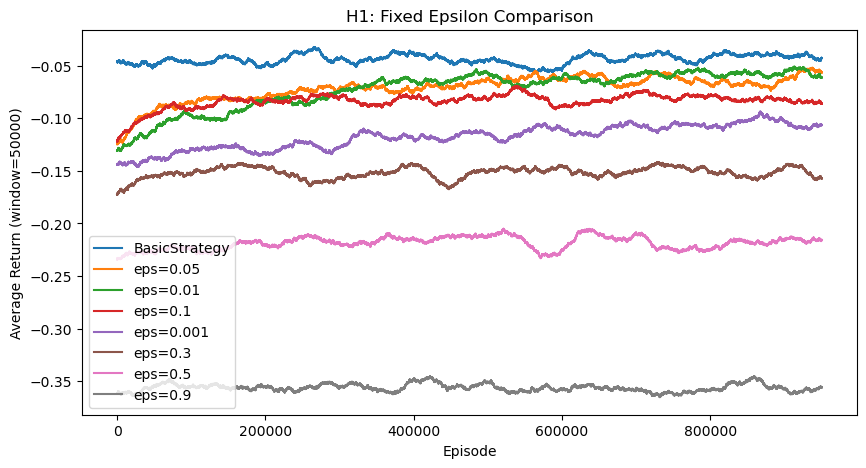

In [29]:
_ = viz.plot_bakeoff_curves(fixed_results, window_size=WINDOW_SIZE,
                              title="H1: Fixed Epsilon Comparison",
                              show_ci=False,
                              save_path="../img/exp1_fixed_epsilon.png")

In [31]:
# Experiment 2: Decay Schedules
# H2: Decaying epsilon over time outperforms any fixed epsilon by exploring
#     broadly early and exploiting later. Schedule shape affects convergence.
from decay_schedules import LinearDecay, ExponentialDecay, CosineDecay, StepDecay

EPS_MIN = 0.001
schedule_builders = {
    "Linear": lambda: LinearDecay(eps_min=EPS_MIN, decay_rate=1/NUM_EPISODES),
    "Exponential": lambda: ExponentialDecay(eps_min=EPS_MIN,
                                             decay_factor=1 - 10/NUM_EPISODES),
    "Cosine": lambda: CosineDecay(eps_start=1.0, eps_min=EPS_MIN,
                                    total_steps=NUM_EPISODES),
    "Step": lambda: StepDecay(eps_min=EPS_MIN, drop_factor=0.5,
                               drop_every=NUM_EPISODES // 5),
}


schedule_results = {}
schedule_agents = {}
schedule_avg = {}
for name, builder in schedule_builders.items():
    schedule = builder()
    agent = BlackjackAgent(epsilon=1.0, decay_schedule=schedule)
    rewards = runner.run_training(agent, num_episodes=NUM_EPISODES)
    schedule_results[name] = rewards
    schedule_agents[name] = agent
    tail_mean = np.mean(rewards[-WINDOW_SIZE:])
    schedule_avg[name] = tail_mean

schedule_results["BasicStrategy"] = basic_rewards

# Identify best performing schedule
best_schedule_name = max(schedule_avg, key=schedule_avg.get)
print(f"\nBest schedule: {best_schedule_name} (avg return={schedule_avg[best_schedule_name]:.3f})")


Best schedule: Exponential (avg return=-0.050)


In [32]:
print_results(schedule_results, tail=WINDOW_SIZE, agents=schedule_agents)

,Agent,Avg Return,95% CI,States,Avg Visits/State
0,BasicStrategy,-0.042,"[-0.051, -0.034]",NaN,NaN
1,Exponential,-0.050,"[-0.059, -0.042]",280.0,2519.6
2,Cosine,-0.066,"[-0.075, -0.058]",280.0,2382.9
3,Linear,-0.076,"[-0.085, -0.068]",280.0,2405.6
4,Step,-0.093,"[-0.101, -0.084]",280.0,2379.3


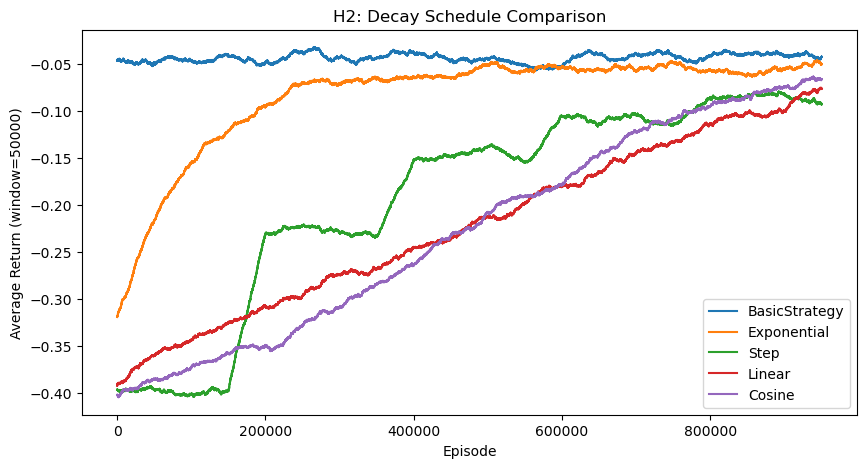

In [33]:
_ = viz.plot_bakeoff_curves(schedule_results, window_size=WINDOW_SIZE,
                              title="H2: Decay Schedule Comparison",
                              show_ci=False,
                              save_path="../img/exp2_decay_schedules.png")


In [34]:
# Experiment 3: Adaptive Decay vs Best Fixed Schedule
# H3: A decay schedule that responds to Q-value estimation confidence
#     outperforms fixed schedules by exploring when uncertain and
#     exploiting when estimates stabilize.
from decay_schedules import AdaptiveDecay


# Adaptive agent
adaptive_agent = BlackjackAgent(epsilon=1.0)
adaptive_agent.decay_schedule = AdaptiveDecay(
    eps_min=0.01, agent=adaptive_agent, sensitivity=0.01)
adaptive_rewards = runner.run_training(
    adaptive_agent, num_episodes=NUM_EPISODES)

# Fresh instance of best schedule from Experiment 2
best_agent = BlackjackAgent(epsilon=1.0,
                             decay_schedule=schedule_builders[best_schedule_name]())
best_rewards = runner.run_training(best_agent, num_episodes=NUM_EPISODES)

best_label = f"{best_schedule_name} Decay"
adaptive_results = {
    "BasicStrategy": basic_rewards,
    "Adaptive Decay": adaptive_rewards,
    best_label: best_rewards,
}

print_results(adaptive_results, tail=WINDOW_SIZE,
              agents={"Adaptive Decay": adaptive_agent,
                      best_label: best_agent})


,Agent,Avg Return,95% CI,States,Avg Visits/State
0,BasicStrategy,-0.042,"[-0.051, -0.034]",NaN,NaN
1,Exponential Decay,-0.059,"[-0.067, -0.050]",280.0,2483.3
2,Adaptive Decay,-0.062,"[-0.071, -0.054]",280.0,2483.2


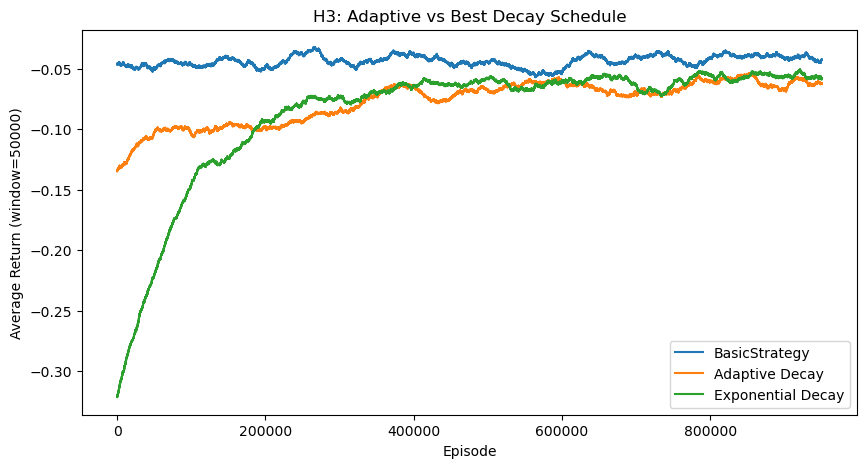

In [35]:
_ = viz.plot_bakeoff_curves(adaptive_results, window_size=WINDOW_SIZE,
                              title="H3: Adaptive vs Best Decay Schedule",
                              show_ci=False,
                              save_path="../img/exp3_adaptive_decay.png")


## BlackjackSimulation (CLI Orchestrator)

In [36]:
# DONE: BlackjackSimulation - stub
# - __init__(NUM_EPISODES, epsilon, decay_schedule, output_dir)
#   - output_dir defaults to W3/img/
# - run(): wire together Agent, EpisodeRunner, BasicStrategy, Visualizer
#   - Train agent, generate all visualizations, save artifacts to output_dir
# - CLI entry point: parse args and call run()

In [37]:
# DONE: BlackjackSimulation - unit tests
# - Test run() completes without error
# - Test CLI arg parsing produces correct configuration
# - Test output artifacts are created in the specified directory